In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset

from sklearn.metrics import (
    classification_report,
    f1_score,
    recall_score,
    precision_score,
    precision_recall_curve,
    auc,
)

from sklearn.metrics import confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

pd.set_option("display.max_colwidth", None)
warnings.filterwarnings("ignore")

import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42

In [2]:
df = pd.read_csv("./materials/final_sets/train_labeled_set.csv")

df = df[df["label"] != " Unknown"]

df_train_set = df.copy()

df["label"].value_counts()

label
Low Risk         213
No Risk          205
Moderate Risk    204
Severe Risk      101
Name: count, dtype: int64

In [3]:
df = pd.read_csv("./materials/final_sets/val_labeled_set.csv")

df = df[df["label"] != " Unknown"]

df_val_set = df.copy()

df["label"].value_counts()

label
Moderate Risk    104
Severe Risk       66
Low Risk          45
No Risk           34
Name: count, dtype: int64

In [4]:
df = pd.read_csv("./materials/final_sets/test_labeled_set.csv")

df = df[df["label"] != " Unknown"]

df_test_set = df.copy()

df["label"].value_counts()

label
No Risk          110
Low Risk          85
Moderate Risk     39
Severe Risk       13
Name: count, dtype: int64

In [5]:
def clean_label(s):
    return str(s).strip().replace("  ", " ")


def clean_text(s):
    s = str(s).strip()
    return s

In [6]:
def prepare_single_split(df, label_map):
    df = df.copy()

    df["text"] = df["text"].apply(clean_text)
    X = df["text"].astype(str).tolist()

    df["label"] = df["label"].apply(clean_label)
    y = df["label"].map(label_map).tolist()

    assert all(pd.notna(x) for x in y), "Unmapped label found in dataset"

    return X, y


def prepare_data(df_train_set, df_val_set, df_test_set):
    label_map = {
        "No Risk": 0,
        "Low Risk": 1,
        "Moderate Risk": 2,
        "Severe Risk": 3,
    }

    label_id = {v: k for k, v in label_map.items()}

    X_train, y_train = prepare_single_split(df_train_set, label_map)
    X_val, y_val = prepare_single_split(df_val_set, label_map)
    X_test, y_test = prepare_single_split(df_test_set, label_map)

    return label_map, label_id, X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
def train_baseline_model(df_train, df_val, df_test, run_name):

    label_map, label_id, X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df_train, df_val, df_test)

    best_score = -1
    best_params = None

    for C in [0.1, 0.5, 1, 1.5, 10, 50, 100, 500]:
        model = LogisticRegression(C=C, solver="saga", max_iter=5000, class_weight="balanced", random_state=SEED)

        tfidf = TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=3,
            smooth_idf=False,
            lowercase=False,
        )

        pipe = Pipeline(
            [
                ("vect", tfidf),
                ("clf", model),
            ]
        )

        pipe.fit(X_train, y_train)

        y_val_pred = pipe.predict(X_val)

        val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")

        print(f"C={C}, Val Macro F1 score: {val_macro_f1:.3f}")

        if val_macro_f1 > best_score:
            best_score = val_macro_f1
            best_params = C

    print(f"Best C = {best_params}, Best F1-Score = {best_score}")

    final_model = LogisticRegression(
        C=best_params, solver="saga", max_iter=5000, class_weight="balanced", random_state=SEED
    )

    final_tfidf = TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=3,
        smooth_idf=False,
        lowercase=False,
    )

    final_pipe = Pipeline(
        [
            ("vect", final_tfidf),
            ("clf", final_model),
        ]
    )

    final_pipe.fit(X_train, y_train)

    y_pred = final_pipe.predict(X_test)

    probs = final_pipe.predict_proba(X_test)

    macro_test_f1 = f1_score(y_test, y_pred, average="macro")

    print()

    print(f"C={best_params}, Test Macro F1 score: {macro_test_f1:.3f}")

    return y_test, y_pred, run_name, probs, label_map, label_id

In [8]:
# I referenced this HuggingFace discussion page for the following class:
# https://discuss.huggingface.co/t/how-can-i-use-class-weights-when-training/1067/14


class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# I referenced the HuggingFace discussion pages for the following class:
# https://discuss.huggingface.co/t/create-a-weighted-loss-function-to-handle-imbalance/138178/2
# https://discuss.huggingface.co/t/training-with-class-weights/62614
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"macro_f1": macro_f1}

In [9]:
def train_bert_model(
    df_train_set,
    df_val_set,
    df_test_set,
    model_name,
    run_name,
    output_dir,
    learning_rate,
    weight_decay,
    random_seed,
):

    label_map, label_id, X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(
        df_train_set,
        df_val_set,
        df_test_set,
    )

    classes = np.arange(len(label_map))

    missing_classes = sorted(set(classes) - set(np.unique(y_train)))
    if missing_classes:
        raise ValueError(f"Training set is missing classes: {missing_classes}")

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    class_weights = torch.tensor(class_weights, dtype=torch.float)

    print("Class weights:", class_weights)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=4,
        id2label=label_id,
        label2id=label_map,
    )

    max_length = 512

    train_encodings = tokenizer(
        X_train,
        truncation=True,
        padding=True,
        max_length=max_length,
    )

    val_encodings = tokenizer(
        X_val,
        truncation=True,
        padding=True,
        max_length=max_length,
    )

    test_encodings = tokenizer(
        X_test,
        truncation=True,
        padding=True,
        max_length=max_length,
    )

    train_dataset = TextDataset(train_encodings, y_train)
    val_dataset = TextDataset(val_encodings, y_val)
    test_dataset = TextDataset(test_encodings, y_test)

    # I referenced this HuggingFace discussion page for the following (training_args and trainer):
    # https://discuss.huggingface.co/t/create-a-weighted-loss-function-to-handle-imbalance/138178/2

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        weight_decay=weight_decay,
        num_train_epochs=5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=learning_rate,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=False,
        report_to="none",
        seed=random_seed,
    )

    trainer = WeightedTrainer(
        class_weights=class_weights,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

    trainer.train()

    val_metrics = trainer.evaluate()
    print("\nValidation metrics (used for model selection):")
    print(val_metrics)

    test_preds = trainer.predict(test_dataset)
    test_logits = test_preds.predictions

    probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
    y_pred = np.argmax(probs, axis=-1)

    return trainer, model, tokenizer, probs, y_pred, y_test, label_map, label_id, run_name

In [10]:
def plot_confusion_matrix_normalized(conf_matrix, label_names, title, plot):
    row_sums = conf_matrix.sum(axis=1, keepdims=True)

    conf_matrix_norm = np.divide(
        conf_matrix,
        row_sums,
        out=np.zeros_like(conf_matrix, dtype=float),
        where=row_sums != 0,
    )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(9, 8))
    hm = sns.heatmap(
        conf_matrix_norm,
        cmap="PuBu",
        annot=True,
        fmt=".2f",
        xticklabels=label_names,
        yticklabels=label_names,
        vmin=0,
        vmax=1,
        annot_kws={"size": 14, "weight": "bold"},
    )
    plt.xlabel("Predicted", fontsize=16, fontweight="bold")
    plt.ylabel("True", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(title, fontsize=18, fontweight="bold", pad=20)
    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=14)
    plt.tight_layout()
    plt.savefig(plot, dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
def evaluate_multiclass(y_true, y_pred, run_name, label_map, label_id):
    y_pred_labels = [label_id[i] for i in y_pred]
    y_true_labels = [label_id[i] for i in y_true]

    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{run_name} test macro-f1: {macro_f1:.3f}")

    print("\nMulticlass classification report:")
    print(classification_report(y_true_labels, y_pred_labels, digits=3))

    label_names = list(label_map.keys())

    conf_matrix = confusion_matrix(y_true_labels, y_pred_labels, labels=label_names)

    plot_confusion_matrix_normalized(
        conf_matrix,
        label_names,
        f"Multiclass Confusion Matrix - {run_name}",
        f"./materials/saved_images/Multiclass_Confusion_Matrix_{run_name}.png",
    )


def evaluate_binary_highrisk(y_true, y_pred, probs, run_name):
    y_true_binary = np.isin(y_true, [2, 3]).astype(int)
    y_pred_binary = np.isin(y_pred, [2, 3]).astype(int)

    highrisk_precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    highrisk_recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    highrisk_f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    print("\nBinary high-risk results:")
    print(f"highrisk_precision: {highrisk_precision:.3f}")
    print(f"highrisk_recall: {highrisk_recall:.3f}")
    print(f"highrisk_f1: {highrisk_f1:.3f}")

    print("\nBinary classification report:")
    print(
        classification_report(
            y_true_binary,
            y_pred_binary,
            target_names=["No/Low Risk", "Moderate/Severe Risk"],
            digits=3,
            zero_division=0,
        )
    )

    binary_conf_matrix = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])

    plot_confusion_matrix_normalized(
        binary_conf_matrix,
        ["No/Low Risk", "Moderate/Severe Risk"],
        f"Binary High-Risk Confusion Matrix - {run_name}",
        f"./materials/saved_images/Binary_HighRisk_Confusion_Matrix_{run_name}.png",
    )

    y_scores_highrisk = probs[:, 2] + probs[:, 3]

    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_scores_highrisk)
    pr_auc = auc(recall, precision)

    print(f"PR-AUC (HighRisk): {pr_auc:.3f}")

    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
    plt.xlabel("Recall", fontsize=16, fontweight="bold")
    plt.ylabel("Precision", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.title(f"Precision-Recall Curve (HighRisk) - {run_name}", fontsize=18, fontweight="bold", pad=20)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc="lower left", fontsize=12, framealpha=0.9, borderpad=1)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"./materials/saved_images/Precision_Recall_{run_name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    

C=0.1, Val Macro F1 score: 0.421
C=0.5, Val Macro F1 score: 0.465
C=1, Val Macro F1 score: 0.467
C=1.5, Val Macro F1 score: 0.479
C=10, Val Macro F1 score: 0.478
C=50, Val Macro F1 score: 0.494
C=100, Val Macro F1 score: 0.506
C=500, Val Macro F1 score: 0.494
Best C = 100, Best F1-Score = 0.5060883286637679

C=100, Test Macro F1 score: 0.494

Final test set evaluation on baseline model:
LogisticRegression test macro-f1: 0.494

Multiclass classification report:
               precision    recall  f1-score   support

     Low Risk      0.467     0.412     0.438        85
Moderate Risk      0.450     0.462     0.456        39
      No Risk      0.684     0.709     0.696       110
  Severe Risk      0.333     0.462     0.387        13

     accuracy                          0.555       247
    macro avg      0.484     0.511     0.494       247
 weighted avg      0.554     0.555     0.553       247



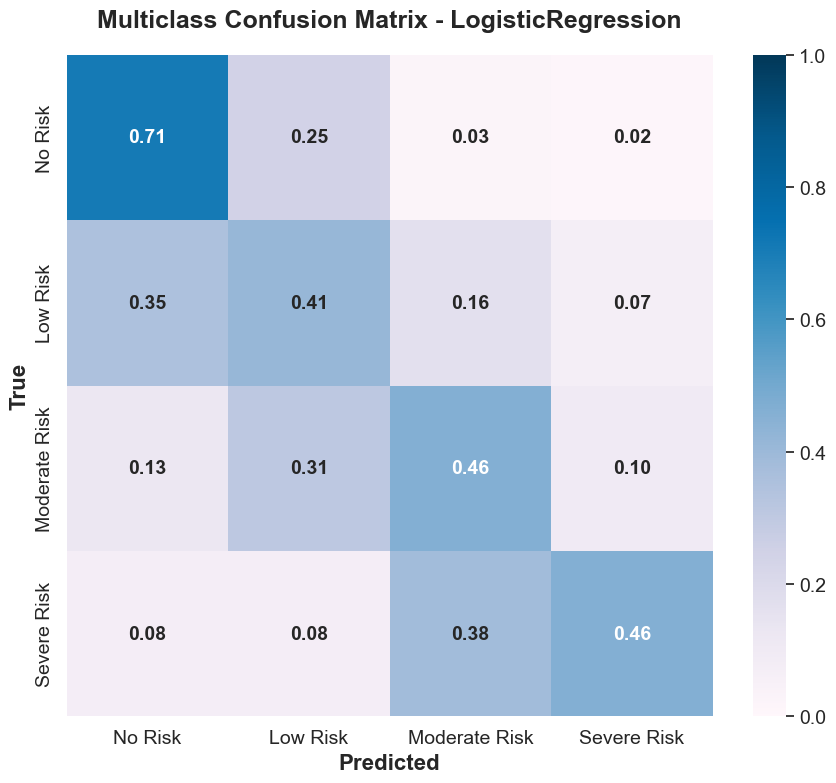


Binary high-risk results:
highrisk_precision: 0.569
highrisk_recall: 0.635
highrisk_f1: 0.600

Binary classification report:
                      precision    recall  f1-score   support

         No/Low Risk      0.899     0.872     0.885       195
Moderate/Severe Risk      0.569     0.635     0.600        52

            accuracy                          0.822       247
           macro avg      0.734     0.753     0.743       247
        weighted avg      0.830     0.822     0.825       247



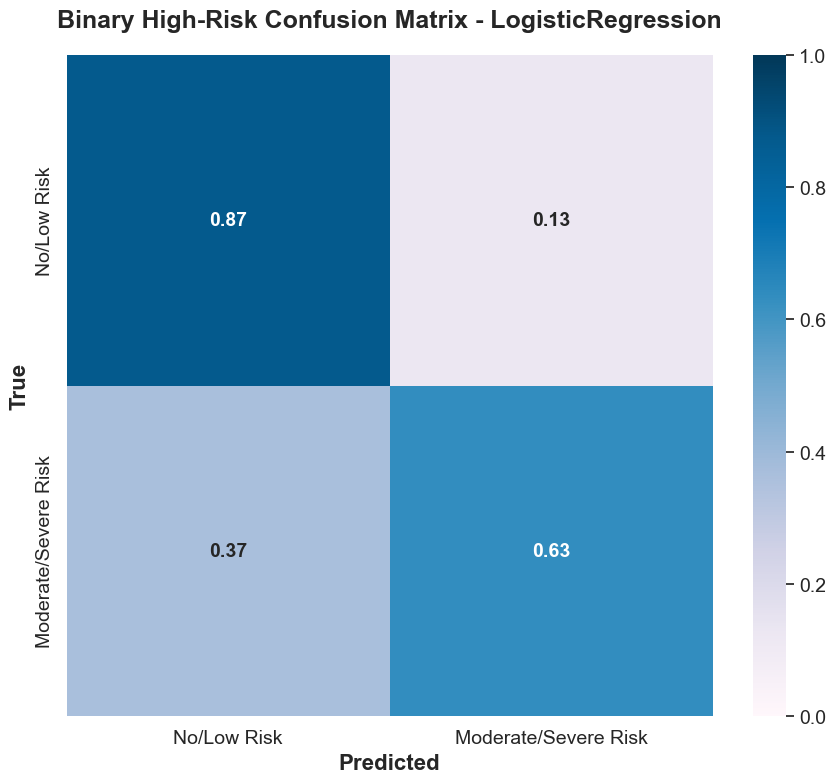

PR-AUC (HighRisk): 0.666


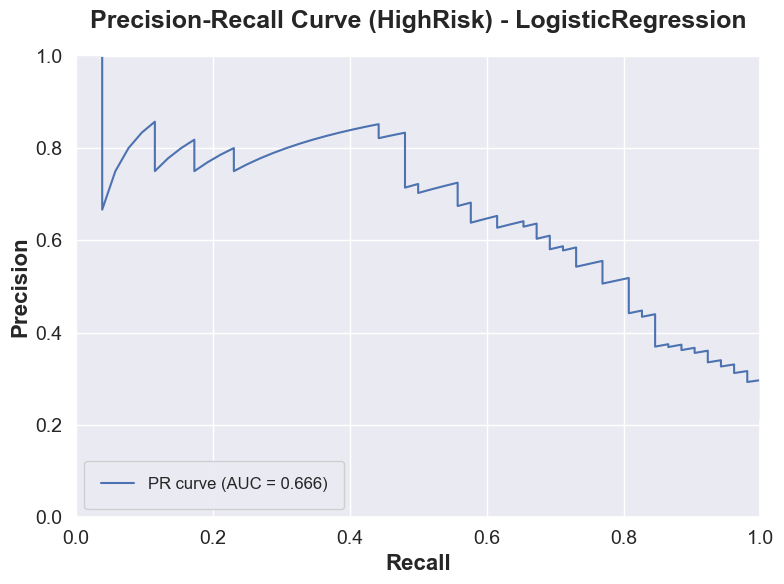

In [12]:
y_test, y_pred, run_name, probs, label_map, label_id = train_baseline_model(
    df_train_set.copy(), df_val_set.copy(), df_test_set.copy(), "LogisticRegression"
)

print("\nFinal test set evaluation on baseline model:")
evaluate_multiclass(y_test, y_pred, run_name, label_map, label_id)
evaluate_binary_highrisk(y_test, y_pred, probs, run_name)

Class weights: tensor([0.8817, 0.8486, 0.8860, 1.7896])


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.247000,0.984159,0.544728
2,0.875400,0.877664,0.501966
3,0.597300,0.913027,0.612637
4,0.390300,0.953860,0.651662
5,0.233300,0.972214,0.640308



Validation metrics (used for model selection):
{'eval_loss': 0.9538597464561462, 'eval_macro_f1': 0.6516615999876065, 'eval_runtime': 18.1402, 'eval_samples_per_second': 13.726, 'eval_steps_per_second': 1.764, 'epoch': 5.0}

Final test set evaluation:
RoBERTa test macro-f1: 0.697

Multiclass classification report:
               precision    recall  f1-score   support

     Low Risk      0.740     0.671     0.704        85
Moderate Risk      0.714     0.641     0.676        39
      No Risk      0.805     0.900     0.850       110
  Severe Risk      0.583     0.538     0.560        13

     accuracy                          0.761       247
    macro avg      0.711     0.688     0.697       247
 weighted avg      0.757     0.761     0.757       247



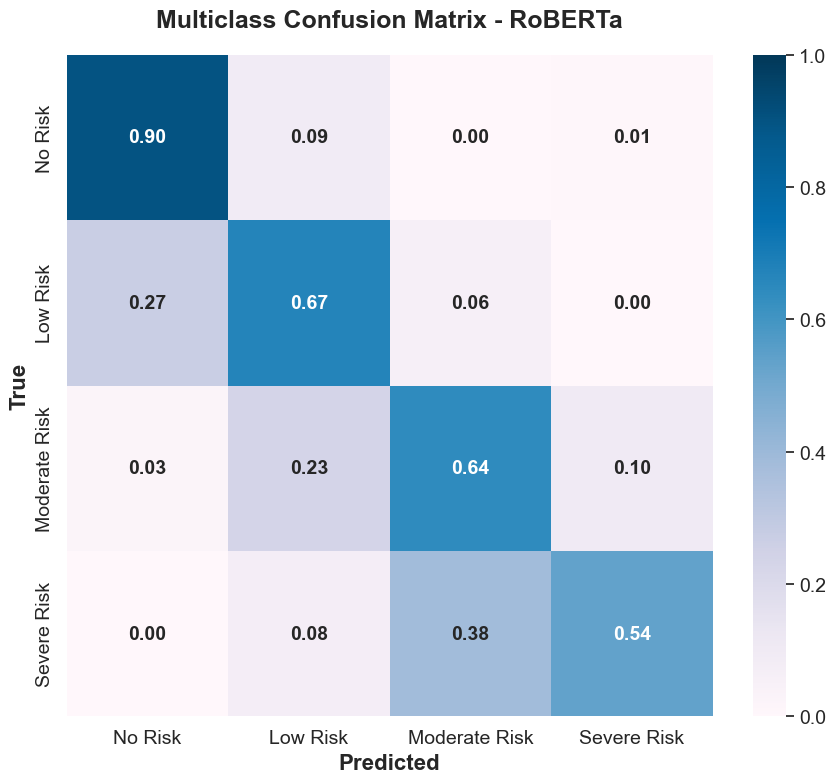


Binary high-risk results:
highrisk_precision: 0.872
highrisk_recall: 0.788
highrisk_f1: 0.828

Binary classification report:
                      precision    recall  f1-score   support

         No/Low Risk      0.945     0.969     0.957       195
Moderate/Severe Risk      0.872     0.788     0.828        52

            accuracy                          0.931       247
           macro avg      0.909     0.879     0.893       247
        weighted avg      0.930     0.931     0.930       247



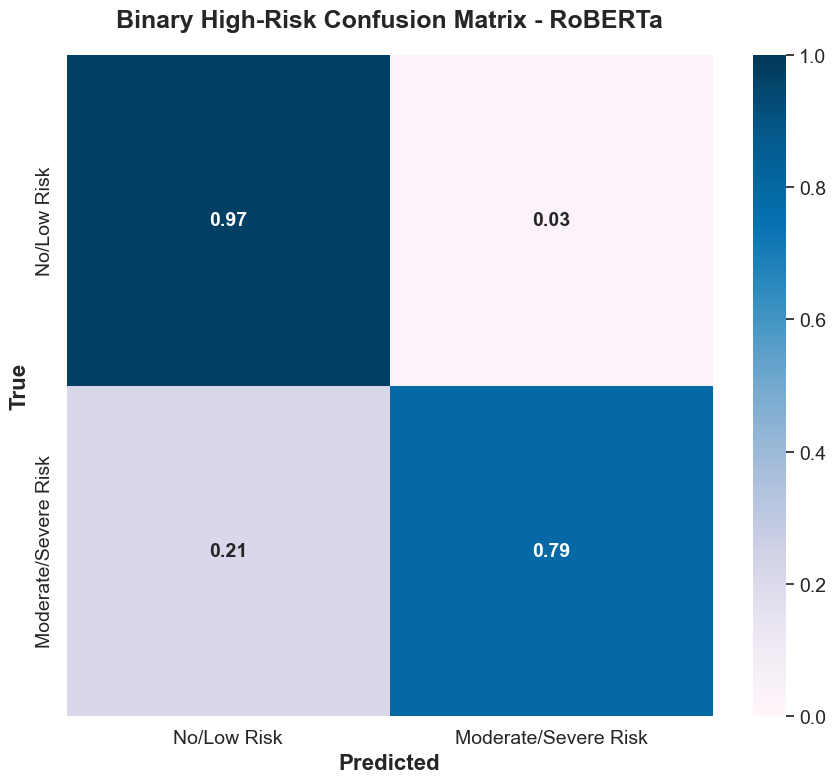

PR-AUC (HighRisk): 0.884


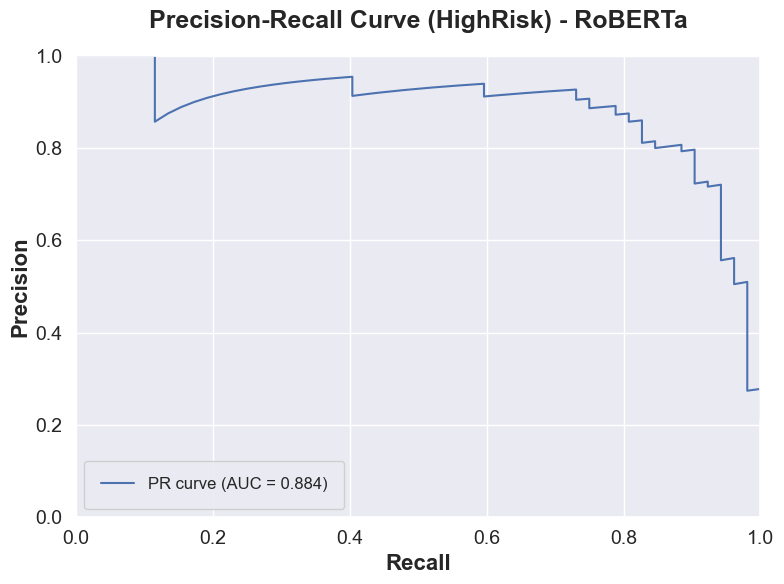

In [13]:
trainer, model, tokenizer, probs, y_pred, y_test, label_map, label_id, run_name = train_bert_model(
    df_train_set=df_train_set.copy(),
    df_val_set=df_val_set.copy(),
    df_test_set=df_test_set.copy(),
    model_name="roberta-base",
    run_name="RoBERTa",
    output_dir="./roberta_output",
    learning_rate=3e-5,
    weight_decay=0.03,
    random_seed=SEED,
)

print("\nFinal test set evaluation:")
evaluate_multiclass(y_test, y_pred, run_name, label_map, label_id)
evaluate_binary_highrisk(y_test, y_pred, probs, run_name)

Class weights: tensor([0.8817, 0.8486, 0.8860, 1.7896])


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.291200,1.125908,0.380292
2,0.955200,0.951341,0.510005
3,0.730100,0.918465,0.535768
4,0.548900,0.984971,0.576282
5,0.423300,0.990655,0.587443



Validation metrics (used for model selection):
{'eval_loss': 0.9906553626060486, 'eval_macro_f1': 0.5874427046417504, 'eval_runtime': 9.9055, 'eval_samples_per_second': 25.138, 'eval_steps_per_second': 3.231, 'epoch': 5.0}

Final test set evaluation:
DistilBERT test macro-f1: 0.568

Multiclass classification report:
               precision    recall  f1-score   support

     Low Risk      0.605     0.612     0.608        85
Moderate Risk      0.556     0.513     0.533        39
      No Risk      0.741     0.755     0.748       110
  Severe Risk      0.385     0.385     0.385        13

     accuracy                          0.648       247
    macro avg      0.571     0.566     0.568       247
 weighted avg      0.646     0.648     0.647       247



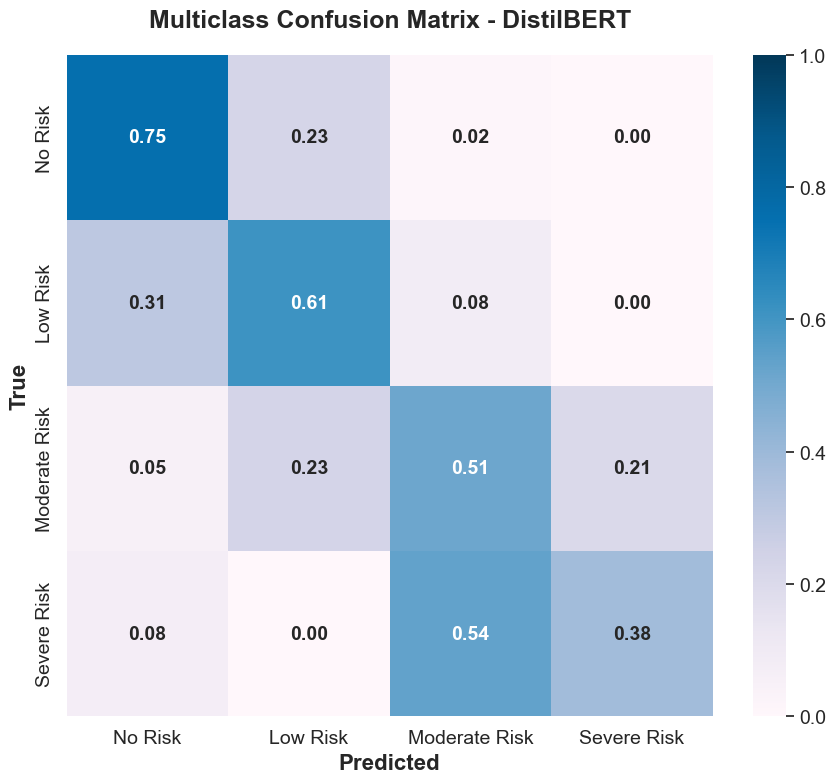


Binary high-risk results:
highrisk_precision: 0.816
highrisk_recall: 0.769
highrisk_f1: 0.792

Binary classification report:
                      precision    recall  f1-score   support

         No/Low Risk      0.939     0.954     0.947       195
Moderate/Severe Risk      0.816     0.769     0.792        52

            accuracy                          0.915       247
           macro avg      0.878     0.862     0.869       247
        weighted avg      0.913     0.915     0.914       247



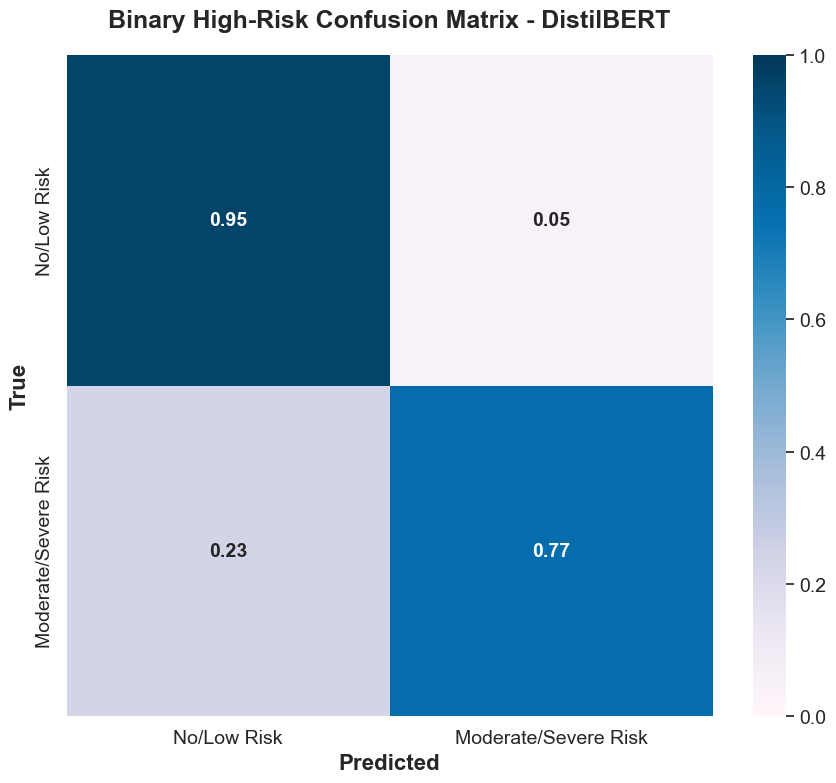

PR-AUC (HighRisk): 0.838


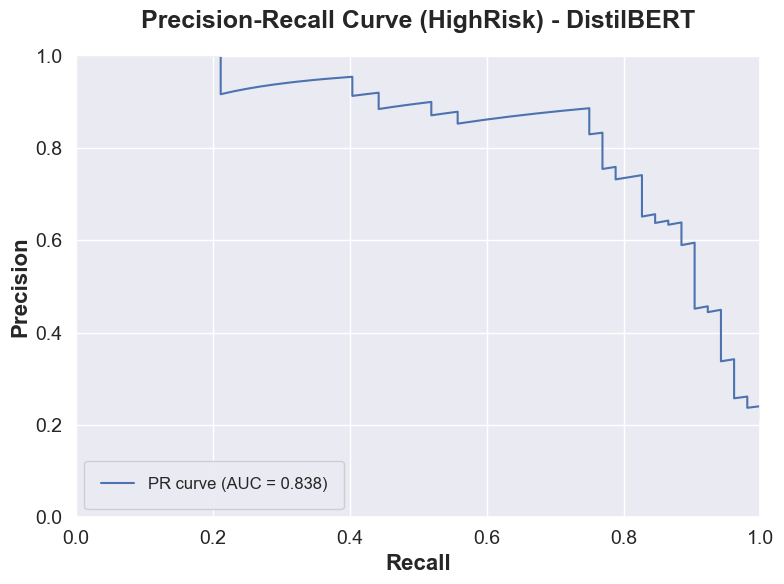

In [14]:
trainer, model, tokenizer, probs, y_pred, y_test, label_map, label_id, run_name = train_bert_model(
    df_train_set=df_train_set.copy(),
    df_val_set=df_val_set.copy(),
    df_test_set=df_test_set.copy(),
    model_name="distilbert-base-uncased",
    run_name="DistilBERT",
    output_dir="./distilbert_output",
    learning_rate=3e-5,
    weight_decay=0.03,
    random_seed=SEED,
)

print("\nFinal test set evaluation:")
evaluate_multiclass(y_test, y_pred, run_name, label_map, label_id)
evaluate_binary_highrisk(y_test, y_pred, probs, run_name)

Class weights: tensor([0.8817, 0.8486, 0.8860, 1.7896])


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.301400,1.075509,0.439966
2,1.010100,0.926874,0.561732
3,0.863100,0.897880,0.522502
4,0.783900,0.883701,0.548250
5,0.715200,0.870789,0.540913



Validation metrics (used for model selection):
{'eval_loss': 0.926873505115509, 'eval_macro_f1': 0.5617315984225514, 'eval_runtime': 3.7611, 'eval_samples_per_second': 66.204, 'eval_steps_per_second': 8.508, 'epoch': 5.0}

Final test set evaluation:
SBERT test macro-f1: 0.587

Multiclass classification report:
               precision    recall  f1-score   support

     Low Risk      0.775     0.365     0.496        85
Moderate Risk      0.551     0.692     0.614        39
      No Risk      0.683     0.900     0.776       110
  Severe Risk      0.462     0.462     0.462        13

     accuracy                          0.660       247
    macro avg      0.618     0.605     0.587       247
 weighted avg      0.682     0.660     0.638       247



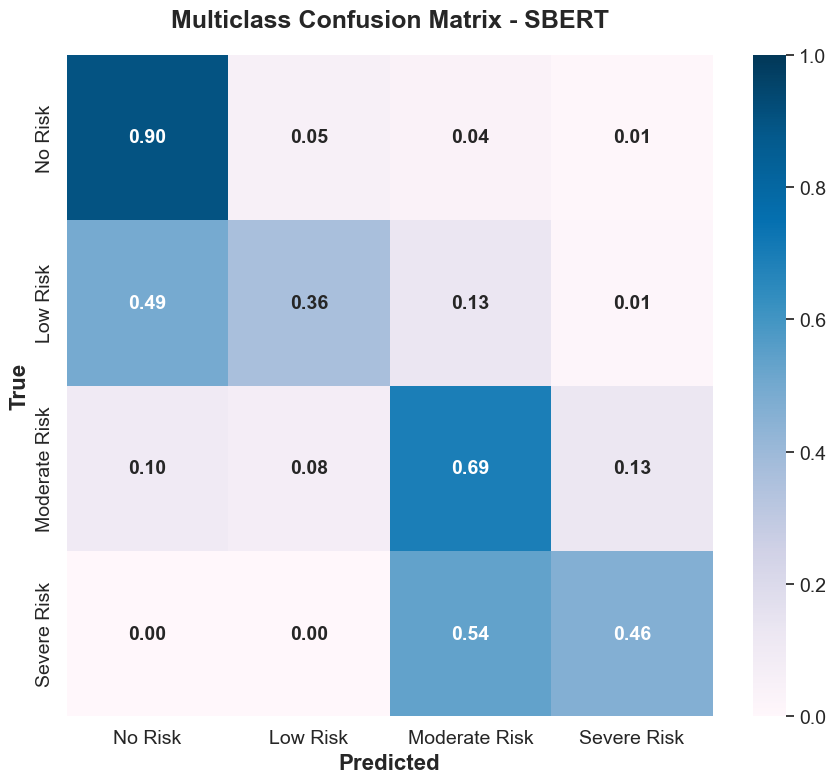


Binary high-risk results:
highrisk_precision: 0.726
highrisk_recall: 0.865
highrisk_f1: 0.789

Binary classification report:
                      precision    recall  f1-score   support

         No/Low Risk      0.962     0.913     0.937       195
Moderate/Severe Risk      0.726     0.865     0.789        52

            accuracy                          0.903       247
           macro avg      0.844     0.889     0.863       247
        weighted avg      0.912     0.903     0.906       247



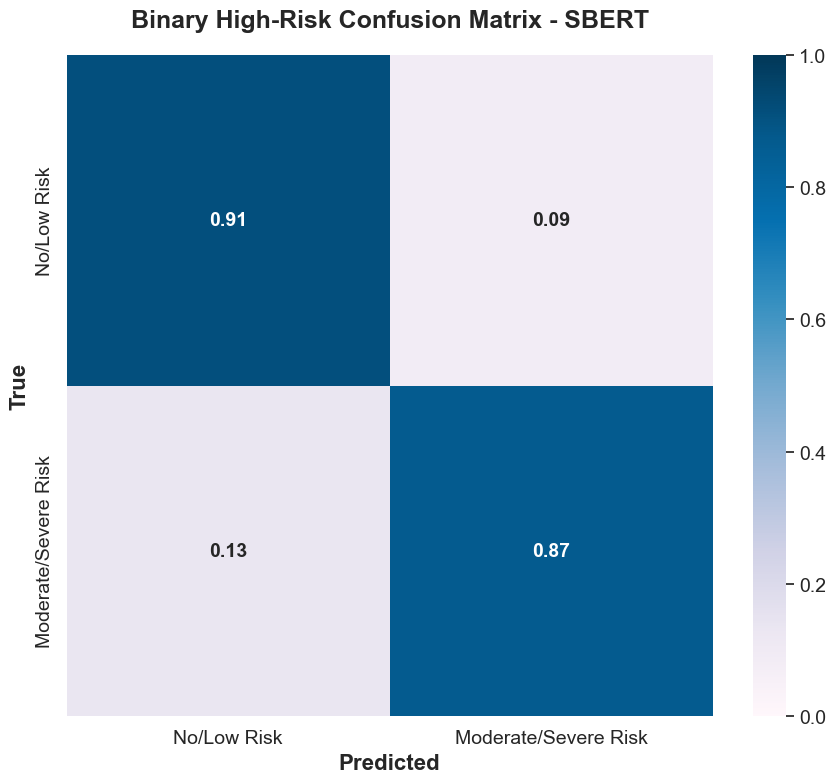

PR-AUC (HighRisk): 0.856


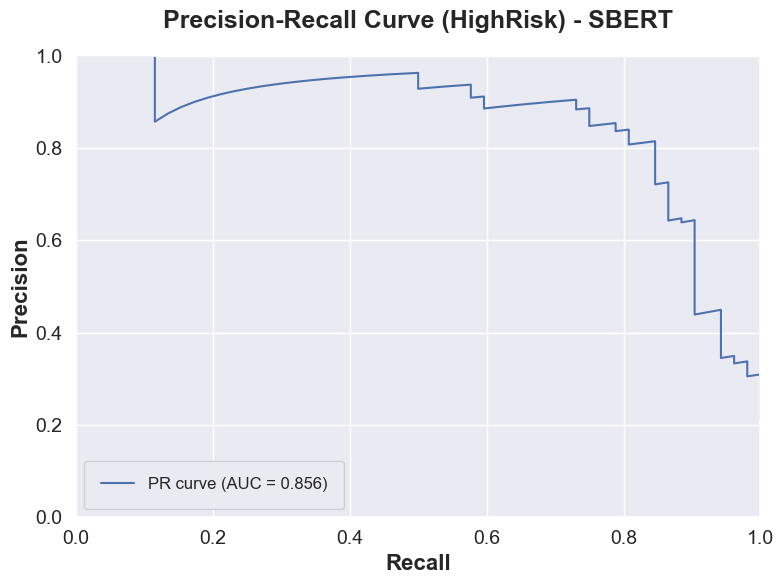

In [15]:
trainer, model, tokenizer, probs, y_pred, y_test, label_map, label_id, run_name = train_bert_model(
    df_train_set=df_train_set.copy(),
    df_val_set=df_val_set.copy(),
    df_test_set=df_test_set.copy(),
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    run_name="SBERT",
    output_dir="./sbert_output",
    learning_rate=3e-5,
    weight_decay=0.03,
    random_seed=SEED,
)

print("\nFinal test set evaluation:")
evaluate_multiclass(y_test, y_pred, run_name, label_map, label_id)
evaluate_binary_highrisk(y_test, y_pred, probs, run_name)

References:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset

https://huggingface.co/docs/transformers/main_classes/trainer

https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments

https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForSequenceClassification

https://huggingface.co/learn/llm-course/en/chapter2/3

https://huggingface.co/docs/transformers/en/model_doc/roberta

https://huggingface.co/docs/transformers/en/model_doc/distilbert

https://sbert.net/

https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

https://seaborn.pydata.org/generated/seaborn.heatmap.html
